s1h2: 0.5515037947328385 +- 0.002841476875482197 (R²=0.9958476732202393)
ba: 0.21686055637333837 +- 0.00030015505847147915 (R²=0.9993515489820872)
conf: 0.26111983393744204 +- 0.0009365734864783769 (R²=0.9970683211896555)
er: 0.15558699887818506 +- 0.0019136723016465905 (R²=0.9623442275599005)


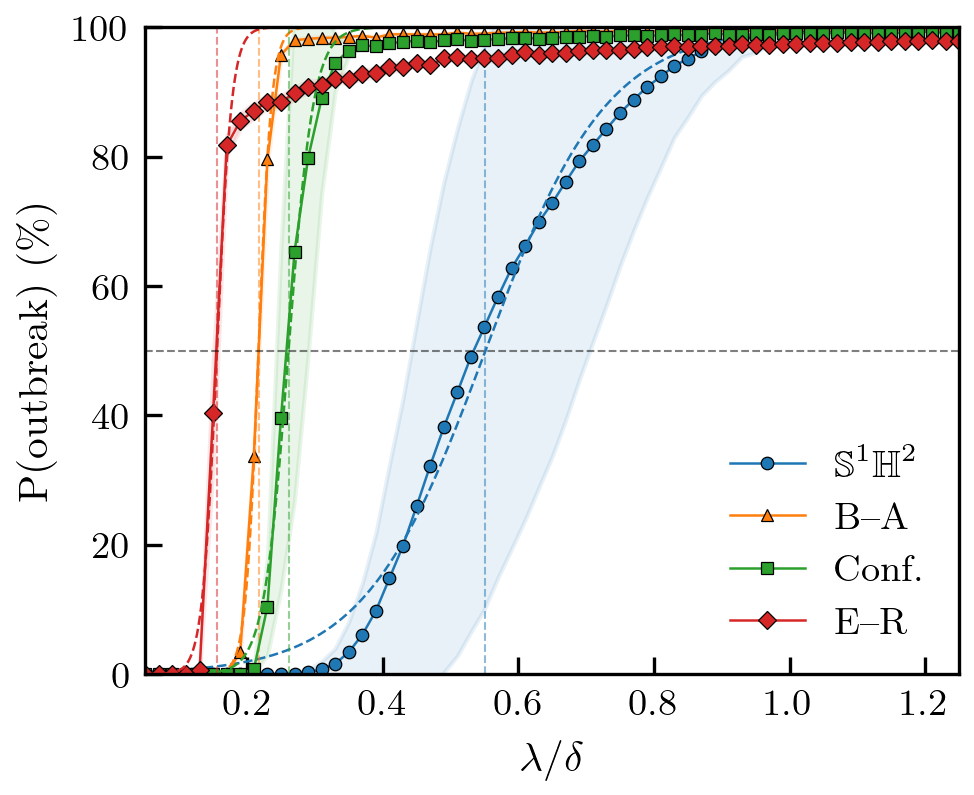

In [19]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pipeline.init as init
from scipy.optimize import curve_fit

def sigmoid(r, r_c, slope):
    """slope > 0 => función creciente"""
    return 1 / (1 + np.exp(-slope * (r - r_c)))

def critical_from_sigmoid(aggregated_df):
    # aggregated_df tiene 'infection_rate' y 'mean' (fracción)
    x = aggregated_df['infection_rate'].values
    y = aggregated_df['mean'].values
    # bounds: r_c entre 0 y 1, slope > 0
    popt, pcov = curve_fit(sigmoid, x, y, p0=[0.5, 700], bounds=([0, 0], [1, np.inf]))
    r_c, slope = popt

    perr = np.sqrt(np.diag(pcov))
    err_rc, err_slope = perr
    y_fit = sigmoid(x, *popt)
    residuals = y- y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    return r_c, err_rc, slope, r_squared

init.configure_matplotlib()
# Confuración
MODELS = ['s1h2', 'ba', 'conf', 'er', ]
NETWORK_SEEDS = [12346, 12347, 12348, 12349]
N = 1000
K = 20
GAMMA = 2.1
BETA = 2.1

# Colores y estilos para los modelos'o', '^', 's', 'D'
model_styles = {
    's1h2': {'color': 'tab:blue', 'marker': 'o', 'label': r'$\mathbb{S}^1\mathbb{H}^2$'},
    'ba': {'color': 'tab:orange', 'marker': '^', 'label': 'B--A'},
    'conf': {'color': 'tab:green', 'marker': 's', 'label': 'Conf.'},
    'er': {'color': 'tab:red', 'marker': 'D', 'label': 'E--R'},
}

def load_success_data(model, net_seed):
    """Carga el archivo success_counts.dat para un modelo y semilla dados."""
    # Construir la ruta base
    if model == 'er':
        base = f'generated-nets/er-s={net_seed}'
    elif model == 'ba':
        base = f'generated-nets/ba-s={net_seed}'
    elif model == 'conf':
        base = f'generated-nets/conf-s={net_seed}'
    elif model == 's1h2':
        base = f'generated-nets/s1h2-s={net_seed}'
    else:
        return None
    
    file_path = os.path.join(base, 'outbreak-size-epidemics', 'success_counts.dat')
    if not os.path.exists(file_path):
        print(f"Archivo no encontrado: {file_path}")
        return None
    
    df = pd.read_csv(file_path, comment='#', sep=r'\s+', names=['infection_rate', 'successes', 'total_simulations'])
    file_path2 = os.path.join(base, 'outbreak-size-epidemics-2', 'success_counts.dat')
    if not os.path.exists(file_path2):
        print(f"Archivo no encontrado: {file_path2}")
        return None
    
    df2 = pd.read_csv(file_path2, comment='#', sep=r'\s+', names=['infection_rate', 'successes', 'total_simulations'])
    df = pd.concat([df, df2], ignore_index=True)
    # Asegurar columnas: infection_rate, successes, total_simulations
    df['fraction'] = df['successes'] / df['total_simulations']
    if (len(df[df['fraction'] > 1.0]) > 0):
        print(f'P > 1.0 in file {file_path}')
    return df

def plot_success_fractions(aggregate=False):
    """
    Genera la gráfica de fracción de brotes exitosos vs i_rate.
    
    Parámetros:
    - aggregate: Si True, promedia sobre las semillas de red de cada modelo
                 y muestra banda de desviación estándar.
                 Si False, muestra todas las curvas individuales (una por semilla).
    """
    fig, ax  = plt.subplots(dpi=300)
    for model in MODELS:
        model_dfs = []
        for seed in NETWORK_SEEDS:
            df = load_success_data(model, seed)
            if df is not None:
                df['net_seed'] = seed
                model_dfs.append(df)
        xs_fit = np.linspace(0, 1, 1000)
        
        if not model_dfs:
            continue
        
        if aggregate:
            # Promediar sobre todas las semillas de red
            # Combinar todos los dataframes y agrupar por infection_rate
            combined = pd.concat(model_dfs, ignore_index=True)
            grouped = combined.groupby('infection_rate')['fraction'].agg(['mean', 'std'])
            grouped.reset_index(inplace=True)
            
            # Graficar línea con banda de error
            x = grouped['infection_rate']
            y_mean = grouped['mean']
            y_std = grouped['std']
            
            ax.plot(x, y_mean, 
                     color=model_styles[model]['color'], 
                     marker=model_styles[model]['marker'], markeredgecolor='black', 
                     label=model_styles[model]['label'], markeredgewidth=0.3,
                     linewidth=0.6, markersize=3)


            r_c, err_rc, slope, r2 = critical_from_sigmoid(grouped)
            
            ax.plot(xs_fit, sigmoid(xs_fit, r_c, slope), '--',
                     color=model_styles[model]['color'], linewidth=0.6)

            ax.axvline(r_c, color=model_styles[model]['color'], linestyle='--', alpha=0.5, linewidth=0.5)
            print(f'{model}: {r_c} +- {err_rc} (R²={r2})')
            # ax.text(r_c+0.01, 0.9, f"{model}: {r_c:.3f}", color=model_styles[model]['color'])
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, 
                             color=model_styles[model]['color'], alpha=0.1)
        else:
            # Graficar cada semilla individualmente (líneas más tenues)
            for df in model_dfs:
                seed = df['net_seed'].iloc[0]
                ax.plot(df['infection_rate'], df['fraction'],
                         color=model_styles[model]['color'], 
                         alpha=0.4, linewidth=1,
                         marker='', linestyle='-')
            # Añadir una línea representativa más gruesa (promedio simple)
            combined = pd.concat(model_dfs, ignore_index=True)
            avg = combined.groupby('infection_rate')['fraction'].mean()
            ax.plot(avg.index, avg.values,
                     color=model_styles[model]['color'],
                     marker=model_styles[model]['marker'],
                     label=model_styles[model]['label'],
                     linewidth=2, markersize=6)
    
    ax.set_xlabel(r'$\lambda/\delta$')
    ax.set_ylabel(r'P(outbreak) (\unit{\%})')
    # ax.title('Probabilidad de epidemia masiva en función de $i_{rate}$', fontsize=14)
    # ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    # plt.tight_layout()
    # plt.savefig('outbreak_success_fraction.png', dpi=150)
    ax.set_ylim(0, 1)
    ax.set_xlim(0.05, 1.25)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
    ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{round(t*100)}" for t in ticks])
    fig.savefig('figs/outbreak-size-critical.pdf')
    plt.show()

plot_success_fractions(aggregate=True)


In [9]:
import pipeline.data as data

def get_network_file(model, net_seed):
    """Return the full path to the edge file for a given model and network seed."""
    base = f'generated-nets/{model}-s={net_seed}'
    if model == 'er':
        return f'{base}/er-n={N}-k={K}-s={net_seed}.edge'
    elif model == 'ba':
        return f'{base}/ba-n={N}-k={K}-s={net_seed}.edge'
    elif model == 'conf':
        return f'{base}/conf-n={N}-k={K}-g={GAMMA}-s={net_seed}.edge'
    elif model == 's1h2':
        return f'{base}/s1h2-n={N}-k={K}-g={GAMMA}-b={BETA}-s={net_seed}.edge'
    else:
        raise ValueError(f'Unknown model: {model}')
    
import networkx as nx

for model in MODELS:
    for seed in NETWORK_SEEDS:
        G = nx.read_edgelist(get_network_file(model, seed))
        k = [d for n, d in G.degree()]
        k_mean = sum(k)/len(k)
        k2_mean = sum(kk**2 for kk in k)/len(k)
        umbral = k_mean / (k2_mean - k_mean)
        print(f"{model}:      1/<k> = {1/k_mean}, <k>/(<k²>-<k>) = {umbral}")
        

s1h2:      1/<k> = 0.053412621879352834, <k>/(<k²>-<k>) = 0.010116788036326348
s1h2:      1/<k> = 0.0544959128065395, <k>/(<k²>-<k>) = 0.008317468951137703
s1h2:      1/<k> = 0.06390494540783559, <k>/(<k²>-<k>) = 0.01365490024117518
s1h2:      1/<k> = 0.0787139689578714, <k>/(<k²>-<k>) = 0.017070955043420898
ba:      1/<k> = 0.050505050505050504, <k>/(<k²>-<k>) = 0.029052705716633404
ba:      1/<k> = 0.050505050505050504, <k>/(<k²>-<k>) = 0.029591635431051488
ba:      1/<k> = 0.050505050505050504, <k>/(<k²>-<k>) = 0.029821343044849492
ba:      1/<k> = 0.050505050505050504, <k>/(<k²>-<k>) = 0.029326468767310765
conf:      1/<k> = 0.05386189809328881, <k>/(<k²>-<k>) = 0.03137600849041617
conf:      1/<k> = 0.049236829148202856, <k>/(<k²>-<k>) = 0.03142464583449377
conf:      1/<k> = 0.049029221415963914, <k>/(<k²>-<k>) = 0.03022641654835545
conf:      1/<k> = 0.04918839153959666, <k>/(<k²>-<k>) = 0.030333775980662777
er:      1/<k> = 0.0502563071665494, <k>/(<k²>-<k>) = 0.050424214164799